<a href="https://colab.research.google.com/github/Moyohor/Machine_Learning_Projects/blob/main/Copy_of_Malware_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXTRACT THE DATASET FILE


In [ ]:
!unzip '/content/sample_data/PE_Header.csv.zip'

Archive:  /content/sample_data/PE_Header.csv.zip
  inflating: PE_Header.csv           


IMPORTING THE NECESSARY MODULES

In [ ]:
import pandas as pd

# 1. Load the malware dataset
# Replace 'dataset_malware.csv' with the exact name of your uploaded file
df = pd.read_csv('/content/PE_Header.csv')

# 2. Print the shape and column names
print(f"Dataset Shape: {df.shape} (Rows, Columns)")
print("\nFirst 5 Rows of Data:")
print(df.head())

# 3. Check the target distribution
# Usually, the label column is called 'Malware', 'legitimate', or 'Label'
# Let's see the count of safe vs dangerous files
if 'legitimate' in df.columns:
    print("\nClass Distribution (Legitimate vs Malware):")
    print(df['legitimate'].value_counts())
elif 'Malware' in df.columns:
    print("\nClass Distribution (Safe vs Malware):")
    print(df['Malware'].value_counts())


Dataset Shape: (29807, 54) (Rows, Columns)

First 5 Rows of Data:
                                              SHA256  Type  e_magic  e_cblp  \
0  dacbe8cb72dd746539792a50e84965fefef73feaa07b5d...     0    23117     144   
1  d3dc7512ce75db33b2c3063fa99245e9ca9fe3b086462f...     0    23117     144   
2  b350fac81533f02981dc2176ed17163177d92d9405758e...     0    23117     144   
3  dfee618043a47b7b09305df0ca460559d9f567ee246c7b...     0    23117     144   
4  c7b2e4e4fb2fcc44c953673ff57c3d14bdf5d2008f35e9...     0    23117     144   

   e_cp  e_crlc  e_cparhdr  e_minalloc  e_maxalloc  e_ss  ...  SizeOfImage  \
0     3       0          4           0       65535     0  ...       139264   
1     3       0          4           0       65535     0  ...        49152   
2     3       0          4           0       65535     0  ...       532480   
3     3       0          4           0       65535     0  ...      1368064   
4     3       0          4           0       65535     0  ...        

In [ ]:
# 1. Print the unique value counts in the 'Type' column
print("Class Distribution in 'Type' column:")
print(df['Type'].value_counts())

# 2. Drop the SHA256 column because unique file hashes cause overfitting
if 'SHA256' in df.columns:
    df = df.drop(['SHA256'], axis=1)
    print("\nDropped 'SHA256' identifier column successfully.")

# 3. Check for any missing values across all columns
missing_values = df.isnull().sum().sum()
print(f"Total missing values in the dataset: {missing_values}")


Class Distribution in 'Type' column:
Type
4    5104
1    5047
3    4973
2    4864
5    4236
6    3706
0    1877
Name: count, dtype: int64

Dropped 'SHA256' identifier column successfully.
Total missing values in the dataset: 0


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Isolate the features (X) and the target label (y)
X = df.drop(['Type'], axis=1)
y = df['Type']

# 2. Split the dataset into 80% training and 20% validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Splitting complete!")
print(f"Training Features: {X_train.shape}, Training Labels: {y_train.shape}")
print(f"Testing Features: {X_test.shape}, Testing Labels: {y_test.shape}")


Splitting complete!
Training Features: (23845, 52), Training Labels: (23845,)
Testing Features: (5962, 52), Testing Labels: (5962,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize the models
# We limit max_depth on the Decision Tree so we can visualize it clearly later
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the Decision Tree
print("Training Decision Tree...")
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# 3. Train the Random Forest
print("Training Random Forest...")
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 4. Print Overall Accuracy Benchmarks
print("\n================ Accuracy Comparison ================")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_preds):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}")


Training Decision Tree...
Training Random Forest...

================ Accuracy Comparison ================
Decision Tree Accuracy: 0.7024
Random Forest Accuracy: 0.8883


In [ ]:
# 1. Print evaluation report for the Decision Tree
print("================ DECISION TREE DETAILED REPORT ================")
print(classification_report(y_test, dt_preds))

# 2. Print evaluation report for the Random Forest
print("\n================ RANDOM FOREST DETAILED REPORT ================")
print(classification_report(y_test, rf_preds))


================ DECISION TREE DETAILED REPORT ================
              precision    recall  f1-score   support

           0       0.89      0.75      0.81       375
           1       0.80      0.82      0.81      1010
           2       0.66      0.95      0.78       973
           3       0.89      0.58      0.70       995
           4       0.85      0.61      0.71      1021
           5       0.49      0.50      0.50       847
           6       0.54      0.72      0.62       741

    accuracy                           0.70      5962
   macro avg       0.73      0.70      0.70      5962
weighted avg       0.73      0.70      0.70      5962


================ RANDOM FOREST DETAILED REPORT ================
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       375
           1       0.95      0.94      0.95      1010
           2       0.99      0.99      0.99       973
           3       0.90      0.85      0.87       995
   

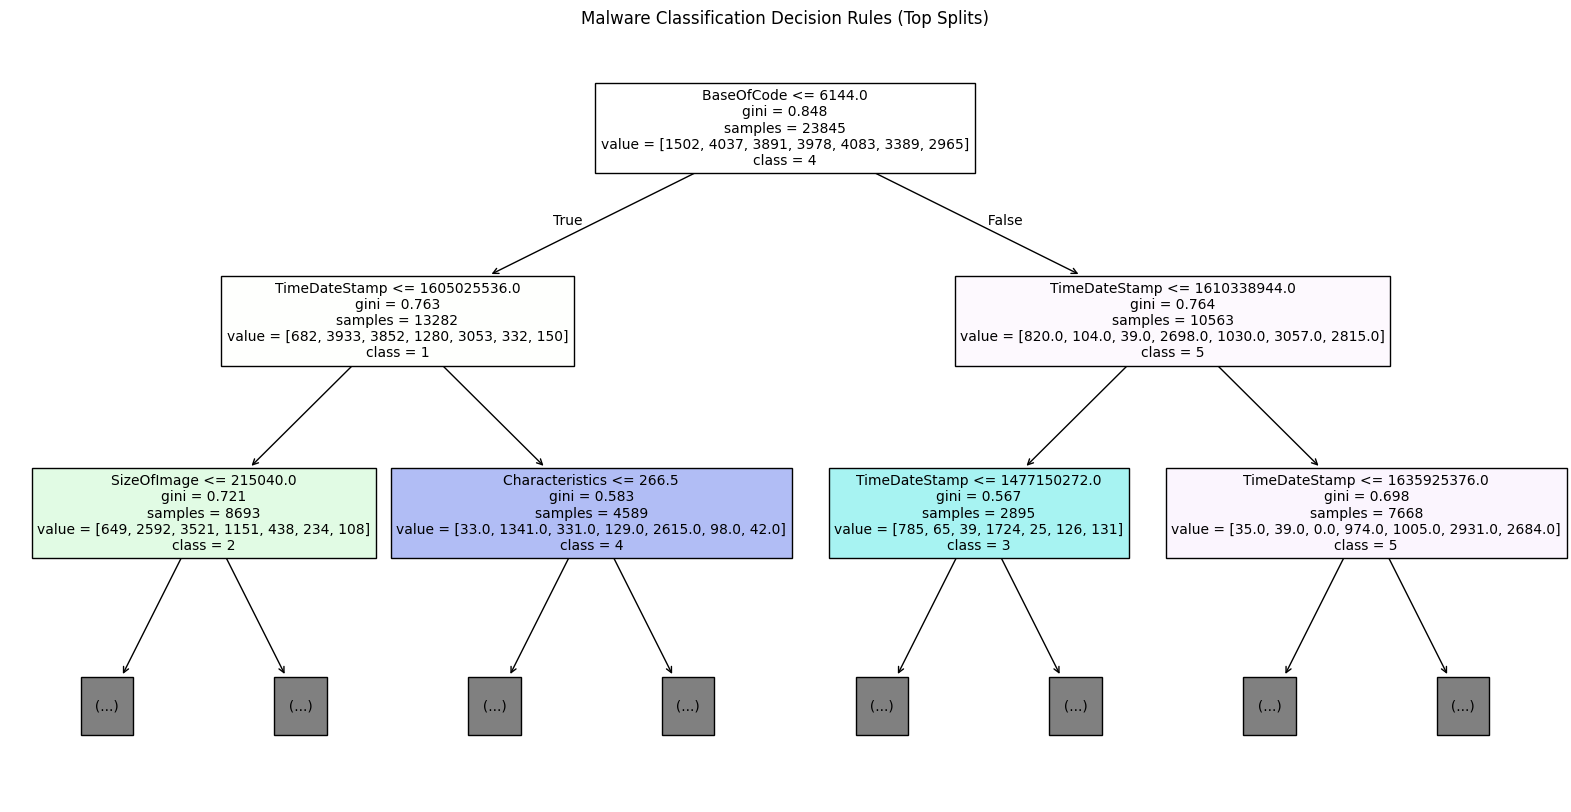

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(i) for i in range(7)],
    filled=True,
    fontsize=10,
    max_depth=2  # Showing just the top layers makes it easy to read
)
plt.title("Malware Classification Decision Rules (Top Splits)")
plt.show()


In [ ]:
import pickle

# Save the trained Random Forest model
model_filename = 'Static_Malware_Detection_.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"Success! Model saved as '{model_filename}'. You can download it from your files tab.")


Success! Model saved as 'Static_Malware_Detection_.pkl'. You can download it from your files tab.
